# 1.Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import random

# 2.Fix Seed

In [2]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

# 3.Dataset selction + PreProcess

In [5]:
dataset = BNCI2014_001()

paradigm = MotorImagery(
    events=["left_hand", "right_hand"],
    n_classes=2,
    fmin=8,
    fmax=35,
    tmin=0.5,
    tmax=3.5,
    resample=128
)

# 4.MOABB

In [6]:
X, labels, metadata = paradigm.get_data(dataset=dataset)

print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("metadata shape:", metadata.shape)

metadata.head()

/home/ali/mlvenv/pytorch_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.1M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/home/ali/mlvenv/pytorch_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/44.2M [00:00<?, ?B/s]

SHA256 hash of downloaded file: d63c454005d3a9b41d8440629482e855afc823339bdd0b5721842a7ee9cc7b12
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/home/ali/mlvenv/pytorch_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

SHA256 hash of downloaded file: b28d8a262c779c8cad9cc80ee6aa9c5691cfa6617c03befe490a090347ebd15c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/home/ali/mlvenv/pytorch_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/44.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 5d79649a42df9d51215def8ffbdaf1c3f76c54b88b9bbaae721e8c6fd972cc36
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


X shape: (2592, 22, 385)
labels shape: (2592,)
metadata shape: (2592, 3)


,subject,session,run
0,1,0train,0
1,1,0train,0
2,1,0train,0
3,1,0train,0
4,1,0train,0


# 5.Check Classes and Metadata

In [8]:
print("Unique labels:", np.unique(labels))
print()

print(metadata.head())
print()

print("Subjects:", metadata["subject"].unique())
print("Sessions:", metadata["session"].unique())

Unique labels: ['left_hand' 'right_hand']

   subject session run
0        1  0train   0
1        1  0train   0
2        1  0train   0
3        1  0train   0
4        1  0train   0

Subjects: [1 2 3 4 5 6 7 8 9]
Sessions: ['0train' '1test']


# 6.Select one subject for simplicity

In [17]:
subject_id = metadata["subject"].unique()[0]
print(subject_id)

subject_mask = metadata["subject"] == subject_id

X_sub = X[subject_mask]
y_sub = labels[subject_mask]
meta_sub = metadata[subject_mask].reset_index(drop=True)
print("\n")
print("Selected subject:", subject_id)
print("X_sub shape:", X_sub.shape)
print("y_sub shape:", y_sub.shape)
print(meta_sub[["subject", "session", "run"]].head())
print("Sessions:", meta_sub["session"].unique())


1


Selected subject: 1
X_sub shape: (288, 22, 385)
y_sub shape: (288,)
   subject session run
0        1  0train   0
1        1  0train   0
2        1  0train   0
3        1  0train   0
4        1  0train   0
Sessions: ['0train' '1test']


# 7.Encode Labels

In [18]:
le = LabelEncoder()
y_sub_encoded = le.fit_transform(y_sub)

print("Classes:", le.classes_)
print("Encoded labels:", np.unique(y_sub_encoded))


Classes: ['left_hand' 'right_hand']
Encoded labels: [0 1]


# 8.Train/Test 

In [19]:
# Cell 9
import numpy as np
import pandas as pd

print("Available sessions:", meta_sub["session"].unique())
print(meta_sub["session"].value_counts())

train_mask = meta_sub["session"] == "0train"
test_mask = meta_sub["session"] == "1test"

X_train = X_sub[train_mask.values]
y_train = y_sub[train_mask.values]

X_test = X_sub[test_mask.values]
y_test = y_sub[test_mask.values]

meta_train = meta_sub.loc[train_mask].reset_index(drop=True)
meta_test = meta_sub.loc[test_mask].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


Sessions: ['0train' '1test']
X_train shape: (144, 22, 385)
y_train shape: (144,)
X_test shape : (144, 22, 385)
y_test shape : (144,)


# 9.Label --> Number

In [20]:
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)
print("Encoded train labels shape:", y_train_enc.shape)
print("Encoded test labels shape :", y_test_enc.shape)

# نمایش نگاشت کلاس به عدد
class_mapping = {cls_name: idx for idx, cls_name in enumerate(le.classes_)}
print("Class mapping:", class_mapping)

Classes: ['left_hand' 'right_hand']
Encoded train labels shape: (144,)
Encoded test labels shape : (144,)
Class mapping: {np.str_('left_hand'): 0, np.str_('right_hand'): 1}


# 10. Train Data Normalization

In [21]:
# X shape: (trials, channels, samples)

train_mean = X_train.mean(axis=(0, 2), keepdims=True)
train_std = X_train.std(axis=(0, 2), keepdims=True)

# جلوگیری از تقسیم بر صفر
train_std[train_std == 0] = 1.0

X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("X_train_norm shape:", X_train_norm.shape)
print("X_test_norm shape :", X_test_norm.shape)
print("Train mean shape:", train_mean.shape)
print("Train std shape :", train_std.shape)

X_train_norm shape: (144, 22, 385)
X_test_norm shape : (144, 22, 385)
Train mean shape: (1, 22, 1)
Train std shape : (1, 22, 1)


# 11.Adding Chanel --> Deep Learning formate (batch,1,channels,samples)

In [23]:
X_train_dl = X_train_norm[:, np.newaxis, :, :]
X_test_dl = X_test_norm[:, np.newaxis, :, :]

print("X_train_dl shape:", X_train_dl.shape)
print("X_test_dl shape :", X_test_dl.shape)


X_train_dl shape: (144, 1, 22, 385)
X_test_dl shape : (144, 1, 22, 385)


# 12.Tensor + DataLoader

In [25]:
X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of train batches:", len(train_loader))
print("Number of test batches :", len(test_loader))

Number of train batches: 5
Number of test batches : 5


# 13.SimpleEEGNet Model

In [28]:
class SimpleEEGNet(nn.Module):
    def __init__(self, n_classes, n_channels, n_samples, dropout_rate=0.5):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(8),

            nn.Conv2d(8, 16, kernel_size=(n_channels, 1), groups=8, bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8), groups=16, bias=False),
            nn.Conv2d(16, 16, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out = self.block1(dummy)
            out = self.block2(out)
            flattened_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Linear(flattened_dim, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 14.Model, CostFunction and Optimizer

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_classes = len(le.classes_)
n_channels = X_train_dl.shape[2]
n_samples = X_train_dl.shape[3]

model = SimpleEEGNet(
    n_classes=n_classes,
    n_channels=n_channels,
    n_samples=n_samples,
    dropout_rate=0.5
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

Using device: cpu
SimpleEEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=192, out_features

# 15. Training Model Loop

In [31]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# 16.Prediction andEvaluation on testData

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def predict_model(model, loader, device):
    model.eval()

    all_preds = []
    all_probs = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(y_batch.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)

    return y_true, y_pred, y_prob

# 17.Training on epochs

In [36]:
num_epochs = 30

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")


Epoch 01/30 | Train Loss: 0.5253 | Train Acc: 0.7361
Epoch 02/30 | Train Loss: 0.4769 | Train Acc: 0.7708
Epoch 03/30 | Train Loss: 0.4535 | Train Acc: 0.7569
Epoch 04/30 | Train Loss: 0.4811 | Train Acc: 0.7639
Epoch 05/30 | Train Loss: 0.4642 | Train Acc: 0.7708
Epoch 06/30 | Train Loss: 0.4515 | Train Acc: 0.7847
Epoch 07/30 | Train Loss: 0.4542 | Train Acc: 0.7500
Epoch 08/30 | Train Loss: 0.4703 | Train Acc: 0.7708
Epoch 09/30 | Train Loss: 0.4658 | Train Acc: 0.7778
Epoch 10/30 | Train Loss: 0.4286 | Train Acc: 0.7847
Epoch 11/30 | Train Loss: 0.4333 | Train Acc: 0.7917
Epoch 12/30 | Train Loss: 0.4049 | Train Acc: 0.8125
Epoch 13/30 | Train Loss: 0.5016 | Train Acc: 0.7639
Epoch 14/30 | Train Loss: 0.4985 | Train Acc: 0.7431
Epoch 15/30 | Train Loss: 0.4540 | Train Acc: 0.8056
Epoch 16/30 | Train Loss: 0.4045 | Train Acc: 0.8403
Epoch 17/30 | Train Loss: 0.3911 | Train Acc: 0.8333
Epoch 18/30 | Train Loss: 0.4175 | Train Acc: 0.8056
Epoch 19/30 | Train Loss: 0.4396 | Train Acc: 

# 18.Evaluation on Test

In [37]:
y_true, y_pred, y_prob = predict_model(model, test_loader, device)

acc = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

cm = confusion_matrix(y_true, y_pred)

print("Test Accuracy           :", round(acc, 4))
print("Test Precision (macro)  :", round(precision_macro, 4))
print("Test Recall (macro)     :", round(recall_macro, 4))
print("Test F1-score (macro)   :", round(f1_macro, 4))
print("Test Precision (weighted):", round(precision_weighted, 4))
print("Test Recall (weighted)   :", round(recall_weighted, 4))
print("Test F1-score (weighted) :", round(f1_weighted, 4))

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))


Test Accuracy           : 0.8125
Test Precision (macro)  : 0.8553
Test Recall (macro)     : 0.8125
Test F1-score (macro)   : 0.8067
Test Precision (weighted): 0.8553
Test Recall (weighted)   : 0.8125
Test F1-score (weighted) : 0.8067

Confusion Matrix:
[[46 26]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   left_hand       0.98      0.64      0.77        72
  right_hand       0.73      0.99      0.84        72

    accuracy                           0.81       144
   macro avg       0.86      0.81      0.81       144
weighted avg       0.86      0.81      0.81       144



# 19.Confusion Matrix

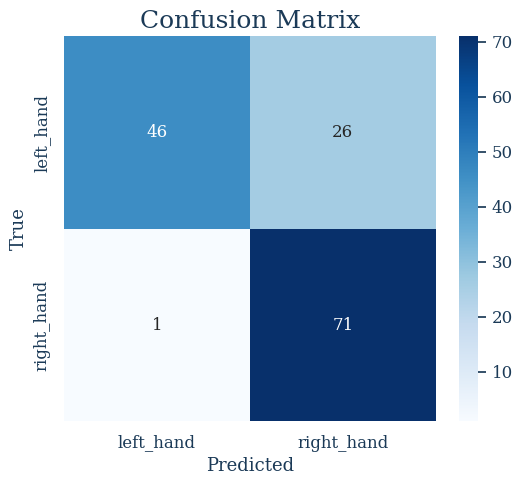

In [38]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# 20.Training procedure

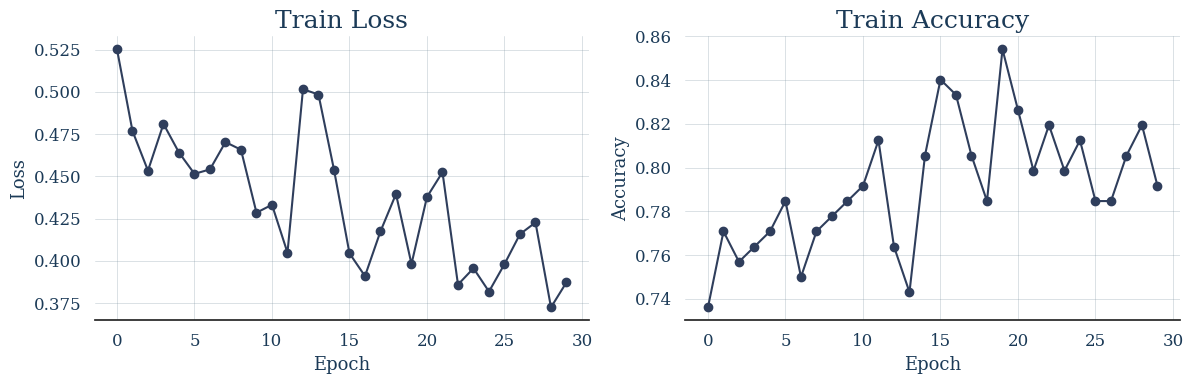

In [39]:
# Cell 21
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker="o")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, marker="o")
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()


# Pipline

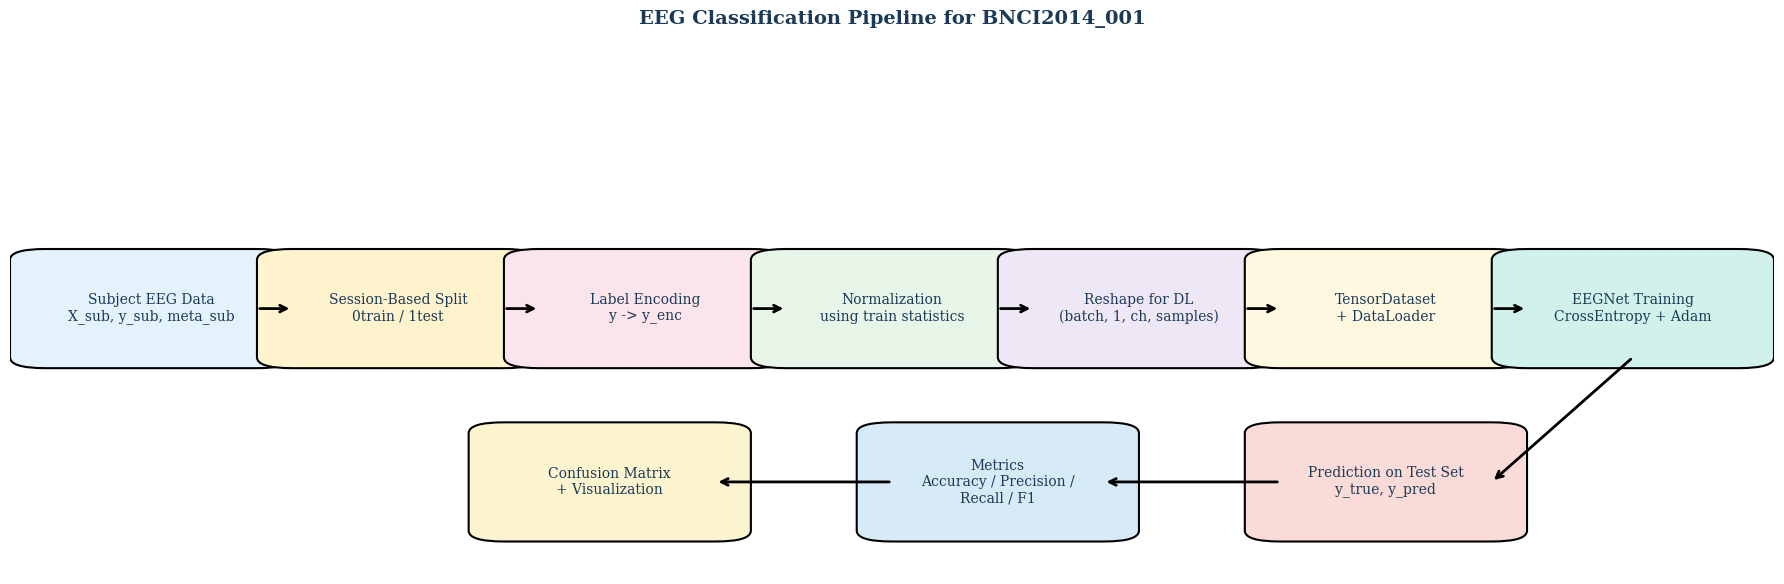

In [42]:
# Cell X - Visual Pipeline Diagram
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def add_box(ax, xy, text, width=0.12, height=0.18, color="#DCEEFF"):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + width/2, y + height/2,
        text,
        ha="center", va="center",
        fontsize=10, wrap=True
    )
    return (x + width, y + height/2)

def add_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=2, color="black")
    )

# Box positions
boxes = [
    ((0.02, 0.4), "Subject EEG Data\nX_sub, y_sub, meta_sub", "#E3F2FD"),
    ((0.16, 0.4), "Session-Based Split\n0train / 1test", "#FFF3CD"),
    ((0.30, 0.4), "Label Encoding\ny -> y_enc", "#FCE4EC"),
    ((0.44, 0.4), "Normalization\nusing train statistics", "#E8F5E9"),
    ((0.58, 0.4), "Reshape for DL\n(batch, 1, ch, samples)", "#EDE7F6"),
    ((0.72, 0.4), "TensorDataset\n+ DataLoader", "#FFF8E1"),
    ((0.86, 0.4), "EEGNet Training\nCrossEntropy + Adam", "#D1F2EB"),
]

# Draw first row
right_points = []
for pos, text, color in boxes:
    right_points.append(add_box(ax, pos, text, color=color))

# Arrows first row
for i in range(len(right_points) - 1):
    start = right_points[i]
    next_x, next_y = boxes[i+1][0]
    end = (next_x, next_y + 0.09)
    add_arrow(ax, start, end)

# Second row
eval_box_pos = (0.72, 0.08)
report_box_pos = (0.50, 0.08)
cm_box_pos = (0.28, 0.08)

add_box(ax, eval_box_pos, "Prediction on Test Set\ny_true, y_pred", color="#FADBD8")
add_box(ax, report_box_pos, "Metrics\nAccuracy / Precision /\nRecall / F1", color="#D6EAF8")
add_box(ax, cm_box_pos, "Confusion Matrix\n+ Visualization", color="#FCF3CF")

# Arrows second row
add_arrow(ax, (0.92, 0.4), (0.84, 0.17))
add_arrow(ax, (0.72, 0.17), (0.62, 0.17))
add_arrow(ax, (0.50, 0.17), (0.40, 0.17))

plt.title("EEG Classification Pipeline for BNCI2014_001", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()
